# Ski Conditions Baseline Model

Goal: train a first weather-only classifier for the folded ski-condition grades `A/B/C/D`.

This model implements a version of ordinal logistic regression.

This is another version of a baseline model that we will be able to compare against. Unlike the multinomial classification, ordinal logistic regression may do a better job understanding the hierarchy of classes present in the data, or that:

$D < C < B < A$

and that for a true label B, an incorrect prediction of C or A is preferred to a prediction for D.

This will hopefully lead to more accurate predictions, and will "cluster" the predictions around the three likely signals.

The following code is from the following sources:

* Ned's multinomial logistic regression model
* https://www.youtube.com/watch?v=E--9kKauJkM
* https://hippocampus-garden.com/ordinal_regression/#:~:text=In%20this%20post%2C%20we%20covered%20three%20approaches,and%20multiple%20thresholds%20to%20model%20cumulative%20probabilities


## setup

In [1]:
!git clone https://github.com/nedcut/ML-final.git
%cd ML-final
!pip install coral_pytorch

import random
from pathlib import Path
import pandas as pd
import torch
from torch import nn
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from coral_pytorch.losses import corn_loss
from coral_pytorch.dataset import corn_label_from_logits

SEED = 42
PROJECT_ROOT = Path.cwd()

DATA_PATH = PROJECT_ROOT / "data/processed/vt_condition_weather_aligned.csv"
TEST_SEASONS = 4
N_EPOCHS = 500
LEARNING_RATE = 0.05

scaler = StandardScaler()

random.seed(SEED)
torch.manual_seed(SEED)


Cloning into 'ML-final'...
remote: Enumerating objects: 103, done.
remote: Counting objects: 100% (103/103), done.
remote: Compressing objects: 100% (74/74), done.
remote: Total 103 (delta 30), reused 57 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (103/103), 11.48 MiB | 4.49 MiB/s, done.
Resolving deltas: 100% (30/30), done.
/content/ML-final


## Load the aligned data


In [3]:
df = pd.read_csv(DATA_PATH)


## Choose features and split by season

Splitting training/testing sequentially, not randomly, preserving time series structure.


In [4]:
class_names = ["A", "B", "C", "D"]
class_to_ix = {name: i for i, name in enumerate(class_names)}

season_order = sorted(df["season_start_year"].unique())
test_years = season_order[-TEST_SEASONS:]
train_years = season_order[:-TEST_SEASONS]

train_df = df[df["season_start_year"].isin(train_years)].copy()
test_df = df[df["season_start_year"].isin(test_years)].copy()

feature_cols = [
    col for col in df.columns
    if (col.startswith("avg_") or col.startswith("best_"))
    and pd.api.types.is_numeric_dtype(df[col])
    and "weather_days_observed" not in col
    and "location_count" not in col
]

print(f"train seasons: {train_df['season'].min()} through {train_df['season'].max()} ({len(train_df)} rows)")
print(f"test seasons:  {test_df['season'].min()} through {test_df['season'].max()} ({len(test_df)} rows)")
print(f"features: {len(feature_cols)}")
feature_cols[:8]


train seasons: 1999-00 through 2020-21 (627 rows)
test seasons:  2021-22 through 2024-25 (114 rows)
features: 52


['avg_hours_above_freezing_sum_7d',
 'avg_hours_above_freezing_mean_7d',
 'avg_hours_above_freezing_max_7d',
 'avg_hours_above_freezing_label_day',
 'avg_temperature_mean_7d',
 'avg_temperature_min_7d',
 'avg_temperature_max_7d',
 'avg_temperature_label_day']

In [6]:
X_train_raw = scaler.fit_transform(train_df[feature_cols].values)
X_test_raw  = scaler.transform(test_df[feature_cols].values)

X_train = torch.tensor(X_train_raw, dtype=torch.float32)
X_test = torch.tensor(X_test_raw, dtype=torch.float32)

#Will make response tensors in evaluation loop
y_train = train_df["grade"].map(class_to_ix).values
y_test = test_df["grade"].map(class_to_ix).values


X_train.shape, y_train.shape, X_test.shape, y_test.shape


(torch.Size([627, 52]), (627,), torch.Size([114, 52]), (114,))

## Ordinal logistic regression

Divides classes into binary probability thresholds:

Predicting 0, 1, 2, or 3 becomes:

Is y larger than 0? ->
Is y larger than 1? ->
Is y larger than 2?

This algorithm uses a "soft label" loss, that uses distance-based weighting to assign probabilities to actual class as well as neighboring classes. This penalizes predictions farther from actual class more heavily.

In [7]:
#### from hippocampus garden

def convert_to_threshold_labels(y):
  arr = []
  for val in y:
    arr.append([1 if val >= 1 else 0,
                1 if val >= 2 else 0,
                1 if val >= 3 else 0])
  return torch.tensor(arr, dtype=torch.float32)

class NeuralNetwork(nn.Module):
  def __init__(self, n_features, hidden_dim, n_classes):
    super().__init__()
    #Ordinal NN relies on probababilities, here:
    #P(rating > D)?
    #P(rating > C)?
    #P(rating > B)? ---> if all true, implies A,
    #so only need 3 classes, or # classes - 1
    self.layer1 = nn.Linear(n_features, hidden_dim)
    self.layer2 = nn.Linear(hidden_dim, n_classes - 1)

  def forward(self, X):
    X = torch.relu(self.layer1(X))
    X = self.layer2(X)
    return X

def train_model(model, X, y, n_classes, epochs=N_EPOCHS, learning_rate=LEARNING_RATE):
    opt = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.BCEWithLogitsLoss()
    losses = []

    y = convert_to_threshold_labels(y)

    for epoch in range(epochs):
        opt.zero_grad()
        scores = model(X)
        loss = loss_fn(scores, y)
        losses.append(loss.item())
        loss.backward()
        opt.step()
        if epoch % 100 == 0:
            print(f"epoch {epoch}: loss={loss.item():.4f}")

    return losses

def predict(model, X):
  with torch.no_grad():
    scores = model(X)
    probs = torch.sigmoid(scores)
    pred_list = []
    #preds stored as 0: [0,0,0]
    #                1: [1,0,0]
    #                2: [1,1,0]...
    for p1, p2, p3 in probs:
      #if 1st val for ith entry is < 1, predict 0
      if p1 < 0.5:
        pred_list.append(0)
      #if 2nd val for ith entry is <1, predict 1...
      elif p2 < 0.5:
        pred_list.append(1)
      elif p3 < 0.5:
        pred_list.append(2)
      else:
        pred_list.append(3)
  return torch.tensor(pred_list, dtype=torch.long)


epoch 0: loss=0.7265
epoch 100: loss=0.0803
epoch 200: loss=0.0224
epoch 300: loss=0.0094
epoch 400: loss=0.0059


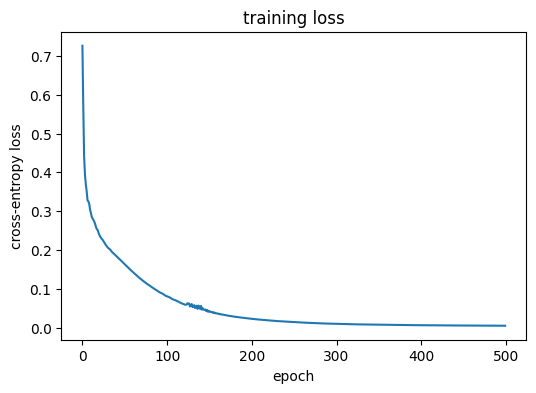

In [27]:
model = NeuralNetwork(n_features=X_train.shape[1], hidden_dim = 16, n_classes=len(class_names))
losses = train_model(model, X_train, y_train, n_classes = len(class_names))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(losses)
ax.set(xlabel="epoch", ylabel="cross-entropy loss", title="training loss")
plt.show()


## Evaluate

Accuracy, confusion matrix, and per-class precision/recall

In [23]:
def predict(model, X):
    with torch.no_grad():
        scores = model(X)
        preds = corn_label_from_logits(scores)
    return preds

def confusion_matrix(y_true, y_pred, n_classes):
    matrix = torch.zeros(n_classes, n_classes, dtype=torch.int64)
    for actual, pred in zip(y_true, y_pred):
        matrix[actual, pred] += 1
    return matrix


def metrics_table(matrix, class_names):
    rows = []
    for i, name in enumerate(class_names):
        tp = matrix[i, i].item()
        predicted = matrix[:, i].sum().item()
        actual = matrix[i, :].sum().item()
        precision = tp / predicted if predicted else 0.0
        recall = tp / actual if actual else 0.0
        rows.append({
            "class": name,
            "precision": precision,
            "recall": recall,
            "actual_count": actual,
            "predicted_count": predicted,
        })
    return pd.DataFrame(rows)


Testing accuracy metrics, also testing how many predictions are accurate or neighboring.

In [28]:
test_preds = predict(model, X_test)
train_preds = predict(model, X_train)

train_acc = (train_preds == y_train).float().mean().item()
test_acc = (test_preds == y_test).float().mean().item()

#testing % of values that are == to actual or neighboring actual
train_diff = (train_preds - y_train).abs()
within_one_train = ((train_diff == 0) | (train_diff == 1)).float().mean().item()

test_diff = (test_preds - y_test).abs()
within_one_test = ((test_diff == 0) | (test_diff == 1)).float().mean().item()

matrix = confusion_matrix(y_test, test_preds, len(class_names))
confusion = pd.DataFrame(matrix.numpy(), index=class_names, columns=class_names)

print(f"train accuracy: {train_acc:.3f}")
print(f"test accuracy:  {test_acc:.3f}")
print(f"within one on training: {within_one_train:.3f}")
print(f"within one on testing:  {within_one_test:.3f}")
confusion



train accuracy: 0.994
test accuracy:  0.596
within one on training: 1.000
within one on testing:  0.895


/tmp/ipykernel_10882/2401625965.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  train_diff = (train_preds - y_train).abs()
/tmp/ipykernel_10882/2401625965.py:11: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  test_diff = (test_preds - y_test).abs()


,A,B,C,D
A,11,10,1,1
B,1,9,6,1
C,4,2,15,7
D,0,5,8,33


In [ ]:
metrics_table(matrix, class_names)


,class,precision,recall,actual_count,predicted_count
0,A,0.833333,0.434783,23,12
1,B,0.307692,0.470588,17,26
2,C,0.444444,0.285714,28,18
3,D,0.706897,0.891304,46,58


This baseline model honestly does not improve predictions significantly over the baseline model, but the logic holds and predictions will hopefully be improved as complexity increases.

## Notes

Things to try next:

- compare avg-only features vs best-snow-only features vs combined features
- sweep the number of held-out seasons
- regularization
- CORN ordinal regression
